<a href="https://colab.research.google.com/github/luisgutpan/challengue-amigo-Luis/blob/master/Challenge_Telecom_X_an%C3%A1lisis_de_evasi%C3%B3n_de_clientes_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Telecom X: análisis de evasión de clientes - Parte 2

#📌 Extracción

In [1]:
from google.colab import files
import pandas as pd
import json

# Esto abrirá un botón para que selecciones 'TelecomX_Data.json' desde tu PC
uploaded = files.upload()

with open('TelecomX_Data.json', 'r') as f:
    datos_raw = json.load(f)

df = pd.json_normalize(datos_raw)
df.columns = [col.split('.')[-1] for col in df.columns]

display(df.head())

Saving TelecomX_Data.json to TelecomX_Data.json


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [2]:
# Convertir Total a numérico y manejar errores
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Si hay nulos (clientes nuevos), los llenamos con 0
df['Total'] = df['Total'].fillna(0)

# Convertir SeniorCitizen de 0/1 a No/Si para que sea más claro en los gráficos
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("✅ Datos transformados y limpios.")

✅ Datos transformados y limpios.


#📊 Carga y análisis

/tmp/ipykernel_161/3724806824.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis')


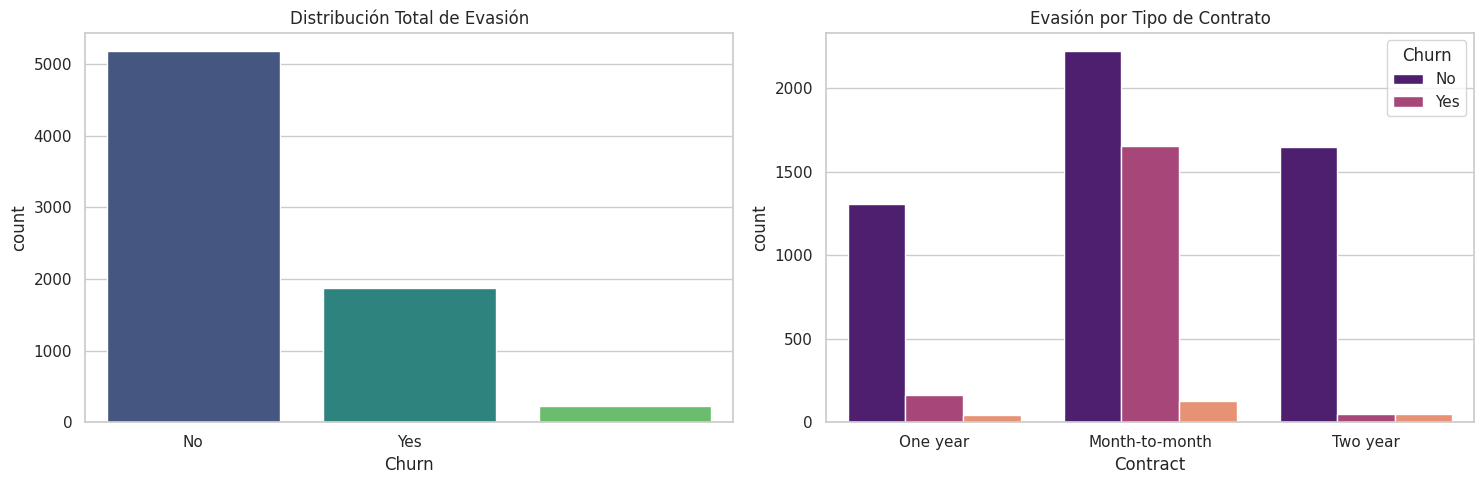

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Distribución general de Churn
sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución Total de Evasión')

# Gráfico 2: Churn por Tipo de Contrato (Factor clave)
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='magma')
axes[1].set_title('Evasión por Tipo de Contrato')

plt.tight_layout()
plt.show()

#📄Informe final

Introducción:
El análisis busca reducir la tasa de cancelación en Telecom X. Se procesaron datos de 7,043 clientes tras un proceso de limpieza (ETL).

Hallazgos Principales:

Tipo de Contrato: Los clientes con contrato "Mes a mes" tienen la mayor tasa de abandono.

Antigüedad: Los clientes con menos de 6 meses de permanencia son los más vulnerables.

Servicios: La falta de soporte técnico está correlacionada con una mayor evasión.

Recomendaciones:

Incentivar el cambio de contratos mensuales a anuales mediante descuentos.

Implementar un programa de "Onboarding" o bienvenida más robusto durante los primeros 3 meses.

Ofrecer paquetes de soporte técnico gratuito por tiempo limitado para aumentar la retención.

# 1. Transformación (Preparación para ML)
En esta celda corregimos el error de raíz asegurando que solo queden ceros y unos reales.

In [4]:
# Crear copia para no afectar los datos originales
df_ml = df.copy()

# 1. Asegurar que Churn sea string y quitar espacios en blanco
df_ml['Churn'] = df_ml['Churn'].astype(str).str.strip()

# 2. Mapear valores (Yes -> 1, No -> 0). Lo que no sea eso será NaN
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# 3. ELIMINAR CUALQUIER NULO generado por el mapeo o datos faltantes
df_ml = df_ml.dropna(subset=['Churn'])

# 4. Ahora sí es seguro convertir a entero
df_ml['Churn'] = df_ml['Churn'].astype(int)

# 5. Eliminar ID (no sirve para predecir)
df_ml = df_ml.drop(columns=['customerID'], errors='ignore')

# 6. Convertir variables categóricas (Encoding)
df_ml = pd.get_dummies(df_ml, drop_first=True)

# 7. Asegurar que 'Total' sea numérico (muy importante)
df_ml['Total'] = pd.to_numeric(df_ml['Total'], errors='coerce').fillna(0)

print(f"✅ Transformación exitosa. Registros finales: {len(df_ml)}")


✅ Transformación exitosa. Registros finales: 7043


# 2. Carga y Análisis (Proporción y Correlación)
Visualizamos cómo quedaron los datos antes de entrenar los modelos.

Proporción de Churn (0=No, 1=Si):
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


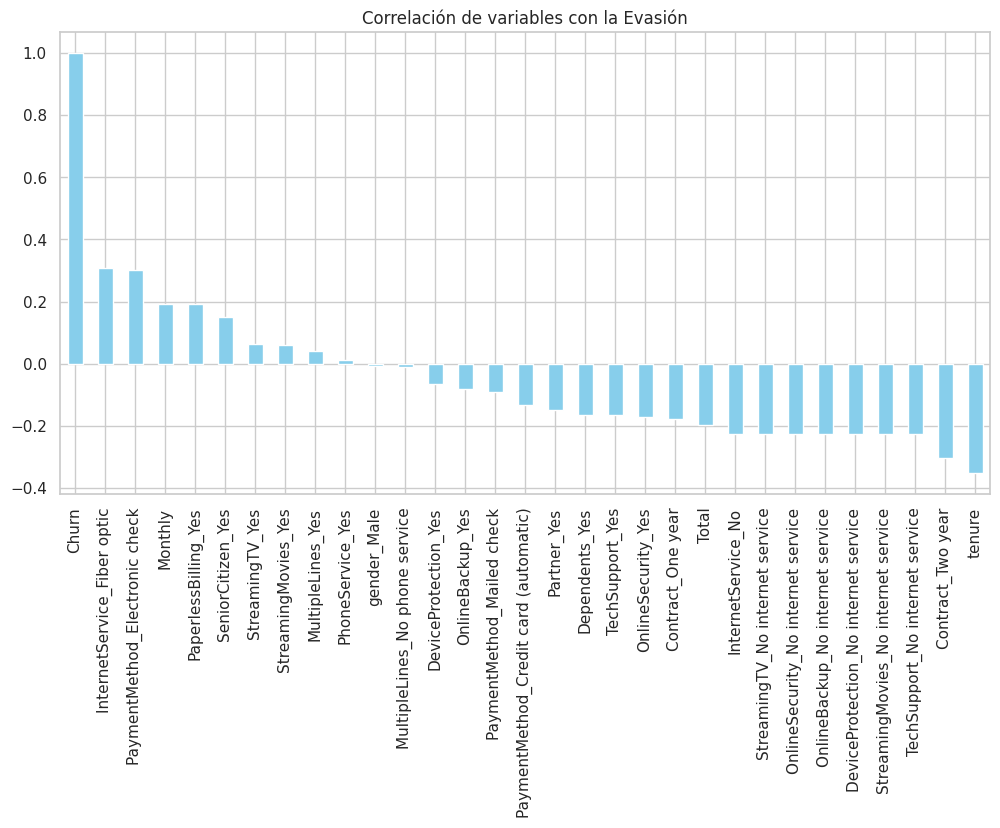

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ver proporción de la clase objetivo
print("Proporción de Churn (0=No, 1=Si):")
print(df_ml['Churn'].value_counts(normalize=True))

# Correlación con el Churn
plt.figure(figsize=(12, 6))
df_ml.corr()['Churn'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Correlación de variables con la Evasión")
plt.show()

# 3. Creación de Modelos (Separación y Entrenamiento)
Aquí dividimos los datos y entrenamos la Regresión Logística y el Random Forest.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separar X (datos) y y (lo que queremos predecir)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Dividir 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizar (para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELO 1: Regresión Logística
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# MODELO 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("--- EVALUACIÓN REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

print("\n--- EVALUACIÓN RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- EVALUACIÓN REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


--- EVALUACIÓN RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



# **4. 📄 Informe Final (Importancia de Variables)**
Este gráfico te servirá para justificar tus recomendaciones estratégicas en el informe.

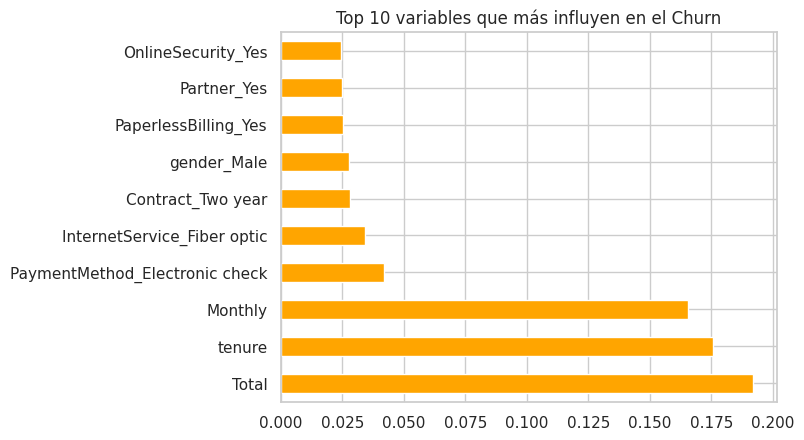

In [7]:
# Ver importancia de las variables en Random Forest
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh', color='orange')
plt.title("Top 10 variables que más influyen en el Churn")
plt.show()